In [2]:
# ==============================================================================
# Cell 1: Imports and System Path Configuration
# ==============================================================================
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Resolve parent directory to import reusable modules from src
current_notebook_dir = os.path.dirname(os.path.abspath("__file__"))
project_root = os.path.abspath(os.path.join(current_notebook_dir, ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.data_loader import OlistDataLoader

# Ingest foundational tables
loader = OlistDataLoader()
orders = loader.load_single_dataset("orders")
items = loader.load_single_dataset("items")
payments = loader.load_single_dataset("payments")
customers = loader.load_single_dataset("customers")

print(f"Data ingestion successful.")
print(f"Orders: {orders.shape}, Items: {items.shape}, Customers: {customers.shape}")

Data ingestion successful.
Orders: (99441, 8), Items: (112650, 7), Customers: (99441, 5)


In [3]:
# ==============================================================================
# Cell 2: Repeat Buyer Target Variable Construction
# ==============================================================================
# 1. Filter completed delivered transactions
orders_delivered = orders[orders["order_status"] == "delivered"].copy()
orders_delivered["order_purchase_timestamp"] = pd.to_datetime(orders_delivered["order_purchase_timestamp"])

# 2. Join unique customer mapping
customer_orders = orders_delivered.merge(
    customers[["customer_id", "customer_unique_id", "customer_state"]],
    on="customer_id",
    how="inner"
)

# 3. Compute historical order volume per customer to construct the binary target
total_orders_per_customer = customer_orders.groupby("customer_unique_id")["order_id"].nunique().rename("total_lifetime_orders")
customer_orders = customer_orders.merge(total_orders_per_customer, on="customer_unique_id", how="left")

# Target definition: 1 if customer ordered more than once, else 0
customer_orders["is_repeat_buyer"] = (customer_orders["total_lifetime_orders"] > 1).astype(int)

# 4. Check class distribution
target_summary = customer_orders.groupby("customer_unique_id")["is_repeat_buyer"].first().value_counts()
target_percentage = (target_summary / target_summary.sum()) * 100

print("--- TARGET CLASS DISTRIBUTION ---")
for label, count in target_summary.items():
    status = "Repeat Buyer (Class 1)" if label == 1 else "One-Time Buyer (Class 0)"
    print(f"{status}: {count:,} ({target_percentage[label]:.2f}%)")

--- TARGET CLASS DISTRIBUTION ---
One-Time Buyer (Class 0): 90,557 (97.00%)
Repeat Buyer (Class 1): 2,801 (3.00%)


In [4]:
# ==============================================================================
# Cell 3: Extract First Transaction Behavioral Features
# ==============================================================================
# Sort chronologically to isolate the customer's very first order
sorted_orders = customer_orders.sort_values(by=["customer_unique_id", "order_purchase_timestamp"])
first_orders = sorted_orders.groupby("customer_unique_id").first().reset_index()

# Aggregate items metrics for the first order
item_features = items.groupby("order_id").agg(
    first_order_items_count=("order_item_id", "count"),
    first_order_spend=("price", "sum"),
    first_order_freight=("freight_value", "sum")
).reset_index()

item_features["first_order_freight_ratio"] = (
    item_features["first_order_freight"] / item_features["first_order_spend"]
).fillna(0.0)

# Aggregate payment preferences for the first order
payment_features = payments.groupby("order_id").agg(
    first_order_payment_type=("payment_type", lambda s: s.mode()[0] if not s.empty else "credit_card"),
    first_order_installments=("payment_installments", "max")
).reset_index()

# Merge all first-order features
first_order_df = first_orders.merge(item_features, on="order_id", how="inner")
first_order_df = first_order_df.merge(payment_features, on="order_id", how="inner")

# Temporal features from the first purchase timestamp
first_order_df["purchase_month"] = first_order_df["order_purchase_timestamp"].dt.month
first_order_df["purchase_hour"] = first_order_df["order_purchase_timestamp"].dt.hour
first_order_df["purchase_dayofweek"] = first_order_df["order_purchase_timestamp"].dt.dayofweek

# Isolate feature matrix
model_data = first_order_df[[
    "first_order_spend",
    "first_order_freight",
    "first_order_freight_ratio",
    "first_order_items_count",
    "first_order_installments",
    "first_order_payment_type",
    "customer_state",
    "purchase_month",
    "purchase_hour",
    "purchase_dayofweek",
    "is_repeat_buyer"
]].copy()

print(f"Modeling dataset assembled: {model_data.shape[0]} rows, {model_data.shape[1]} columns")
model_data.head(3)

Modeling dataset assembled: 93357 rows, 11 columns


,first_order_spend,first_order_freight,first_order_freight_ratio,first_order_items_count,first_order_installments,first_order_payment_type,customer_state,purchase_month,purchase_hour,purchase_dayofweek,is_repeat_buyer
0,129.9,12.00,0.092379,1,8,credit_card,SP,5,10,3,0
1,18.9,8.29,0.438624,1,1,credit_card,SP,5,11,0,0
2,69.0,17.22,0.249565,1,8,credit_card,SC,3,21,4,0


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_30368\1031152802.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=model_data, x="is_repeat_buyer", ax=axes[0], palette=["#3498db", "#e74c3c"])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_30368\1031152802.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["One-Time (97%)", "Repeat Buyer (3%)"])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_30368\1031152802.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=model_data, x="is_repeat_buyer", y="first_order_spend", ax=axes[1], palette=["#3498db", "#e74c3c"])
C:\Users\LENOVO\A

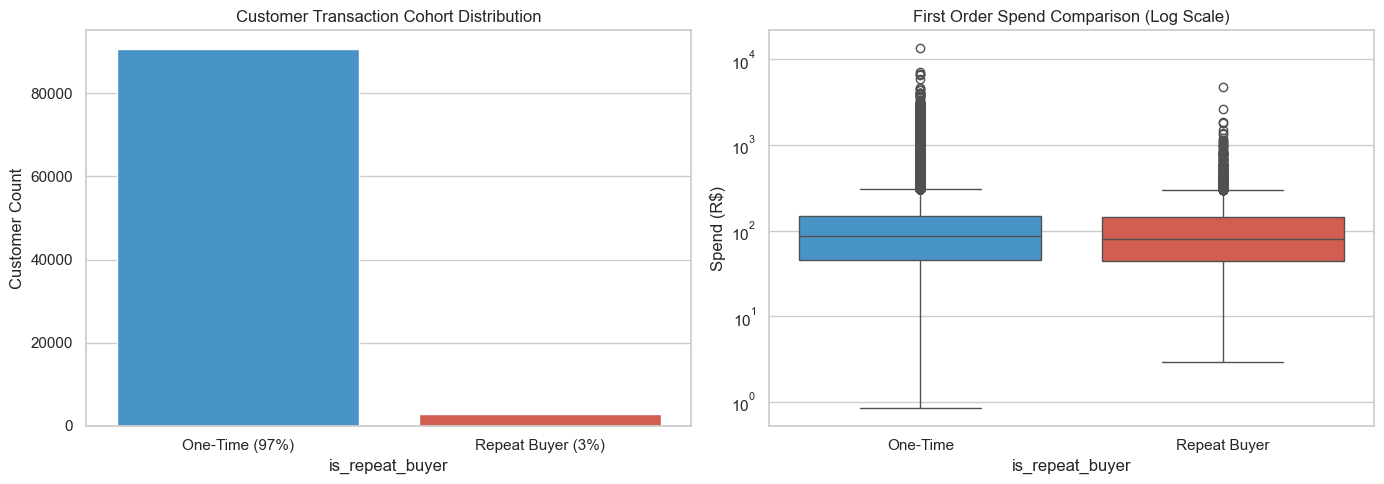

In [5]:
# ==============================================================================
# Cell 4: Distribution & Spend vs. Repeat Buyer Analysis
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Target distribution
sns.countplot(data=model_data, x="is_repeat_buyer", ax=axes[0], palette=["#3498db", "#e74c3c"])
axes[0].set_title("Customer Transaction Cohort Distribution", fontsize=12)
axes[0].set_xticklabels(["One-Time (97%)", "Repeat Buyer (3%)"])
axes[0].set_ylabel("Customer Count")

# Plot 2: Spend comparison on log scale
sns.boxplot(data=model_data, x="is_repeat_buyer", y="first_order_spend", ax=axes[1], palette=["#3498db", "#e74c3c"])
axes[1].set_yscale("log")
axes[1].set_title("First Order Spend Comparison (Log Scale)", fontsize=12)
axes[1].set_xticklabels(["One-Time", "Repeat Buyer"])
axes[1].set_ylabel("Spend (R$)")

plt.tight_layout()
plt.show()

In [6]:
# ==============================================================================
# Cell 5: Preprocessing Pipeline & Stratified Splitting
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier

X = model_data.drop(columns=["is_repeat_buyer"])
y = model_data["is_repeat_buyer"]

# Stratified split to preserve the ~3% positive minority distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

numeric_features = [
    "first_order_spend",
    "first_order_freight",
    "first_order_freight_ratio",
    "first_order_items_count",
    "first_order_installments",
    "purchase_month",
    "purchase_hour",
    "purchase_dayofweek"
]
categorical_features = ["first_order_payment_type", "customer_state"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

# Compute explicit class weights for balanced loss penalization
pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
print(f"Calculated scale_pos_weight: {pos_weight:.2f}")

lgbm_model = LGBMClassifier(
    n_estimators=150,
    learning_rate=0.03,
    max_depth=5,
    scale_pos_weight=pos_weight,
    random_state=42,
    verbosity=-1
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", lgbm_model)
])

print("Pipeline configured successfully.")

Calculated scale_pos_weight: 32.33
Pipeline configured successfully.


ROC-AUC Score : 0.6057
PR-AUC Score  : 0.0453 (Baseline ~0.03)


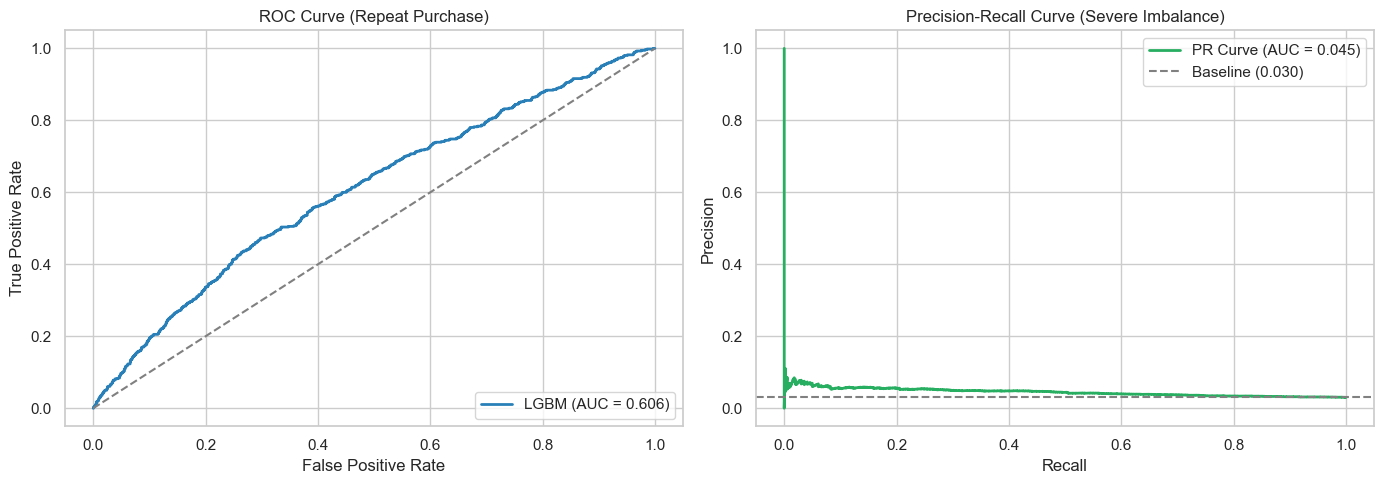

In [7]:
# ==============================================================================
# Cell 6: Training Execution & Validation Metrics
# ==============================================================================
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, roc_curve, precision_recall_curve

# Fit pipeline
pipeline.fit(X_train, y_train)

# Predict probabilities
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

print("=" * 50)
print(f"ROC-AUC Score : {roc_auc:.4f}")
print(f"PR-AUC Score  : {pr_auc:.4f} (Baseline ~0.03)")
print("=" * 50)

# Plot ROC and PR Curves side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color="#2980b9", lw=2, label=f"LGBM (AUC = {roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("ROC Curve (Repeat Purchase)", fontsize=12)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1].plot(recall, precision, color="#27ae60", lw=2, label=f"PR Curve (AUC = {pr_auc:.3f})")
axes[1].axhline(y=y_test.mean(), linestyle="--", color="gray", label=f"Baseline ({y_test.mean():.3f})")
axes[1].set_title("Precision-Recall Curve (Severe Imbalance)", fontsize=12)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_30368\1476369171.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="viridis")


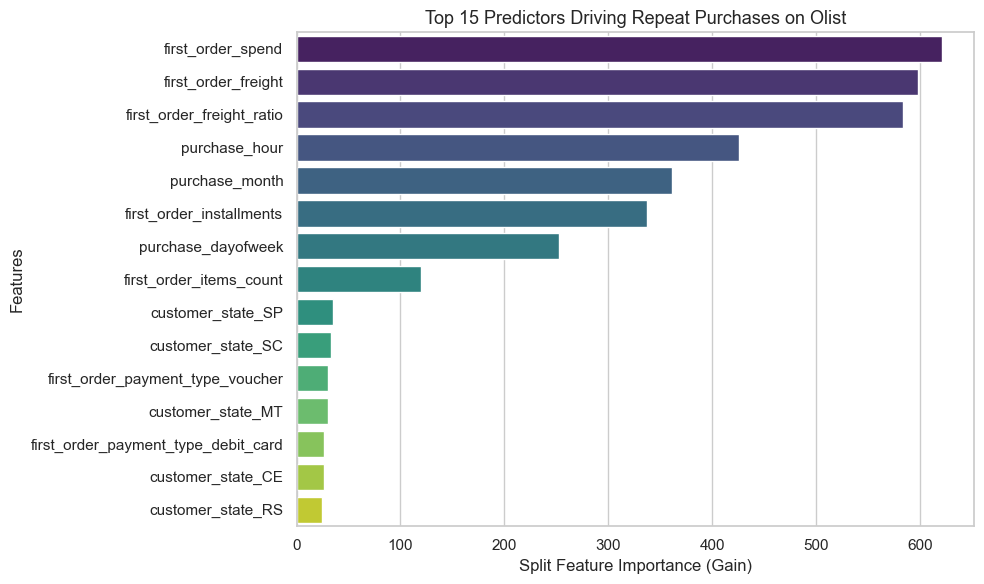

In [8]:
# ==============================================================================
# Cell 7: Feature Importance Extraction
# ==============================================================================
# Extract feature names from fitted ColumnTransformer
fitted_preprocessor = pipeline.named_steps["preprocessor"]
cat_encoder = fitted_preprocessor.named_transformers_["cat"]
cat_encoded_names = cat_encoder.get_feature_names_out(categorical_features).tolist()

all_feature_names = numeric_features + cat_encoded_names
importances = pipeline.named_steps["classifier"].feature_importances_

# Isolate top 15 drivers of repeat purchases
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="viridis")
plt.title("Top 15 Predictors Driving Repeat Purchases on Olist", fontsize=13)
plt.xlabel("Split Feature Importance (Gain)")
plt.ylabel("Features")
plt.tight_layout()
plt.show()